## Introducción a los Métodos Numéricos


En esta sección nos enfocaremos en un proceso conocido como Montecarlo-Markov-Chain MCMC. Para comprender como se desarrolla el proceso primero se revisan los métodos de cadenas de Markov, sus propiedades y aplicaciones en diferentes disciplinas. Luego se aborda el concepto de simulación de montecarlo que permite generar proyecciones de variables aleatorias o estocásticas dependiendo de la proyección que se desee realizar.

### Cadenas de Markov


La cadena de Markov representa una clase de procesos estocásticos en los que el futuro no depende del pasado sino solo del presente. El algoritmo fue propuesto por primera vez por un matemático ruso Andrei Markov. Las cadenas de arkov modelan procesos que evolucionan en pasos que podrían ser en términos de tiempo, ensayos o secuencia. Por lo tanto, por ejemplo, en cada paso el proceso puede existir en varios estados contables. Cuando el proceso evoluciona, el sistema puede permanecer en el mismo estado o cambiar (transición) a un estado diferente durante la época del tiempo. Estos movimientos entre estados se describen normalmente en términos de probabilidades de transición. Estas probabilidades de transición permiten predecir en el futuro la posibilidad de que el sistema esté en un estado, muchas épocas posteriores.

Un proceso estocástico es una cadena de Markov si posee las propiedades de Markov. La propiedad de Markov es simplemente que, para el proceso, los estados pasado y futuro  son independientes si se conoce su estado actual. Para trabajar con tal concepto, es fundamental, por tanto, conocer el estado actual del proceso.

Los estados $X_{n}$ son discretos en la instancia de tiempo $n$. En el momento $n + 1$, el proceso depende solo del estado en el que se encontraba en el momento $n$. Por ejemplo, las personas que se atrazan en crédito con un banco, $X_{n}$ es la cantidad de personas que tienen un crédito en el momento $n$ y que están al día en sus pagos . El número de personas que se atrazó en sus pagoas en el momento $n + 1 $ es $X_{n+1}$. 

De acuerdo a esto el número de personas que se atraza en el pago de sus cutoas en el período $n+1$, depende solo directamente del número de personas que tienen un crédito en el período $n$ y el  proceso de Markov no depende de sus eventos pasados $\{X_{n − 1}, X_{n − 2},. . . , X_{0}\}$.

Una cadena de markov tiene un estado inicial o parcial en el que la variable $X_{n}$ se encuentra antes de moverse al siguiente estado. Un ejemplo puede ser una calificación de riesgo. Una persona que no se atraza en sus pagos es A que es su estado inicial y la probabilidad que se atrece en un mes es de 0.1. Si esto se cumple, la persona deja de tener una calificación A y ahora es B dado que pasa de un estado al siguiente. Esto se puede observa con más detalle en una matriz de transición.



### Ejemplo Cadenas de Markov

In [1]:
import numpy as np
import pandas as pd
transition_prob={"A":{"A":0.9,"B":0.1,"C":0.0,"D":0.0},"B":{"A":0.2,"B":0.7,"C":0.1,"D":0.0},"C":{"A":0.05,"B":0.2,"C":0.6,"D":0.15},"D":{"A":0.0,"B":0.0,"C":0.0,"D":1.0}}
matriz=pd.DataFrame(transition_prob)
matriz.index=["A","B","C","D"]
matriz.columns=["A","B","C","D"]
matriz=matriz.transpose()
print(matriz)

      A    B    C     D
A  0.90  0.1  0.0  0.00
B  0.20  0.7  0.1  0.00
C  0.05  0.2  0.6  0.15
D  0.00  0.0  0.0  1.00


Esta matriz es el resultado de calcular la probabilidad de que un cliente obtenga una calificación de crédito de acuerdo a su historial de pagos en el banco. Las etiquetas de las filas y las columnas representan esta calificación que inicia con A para clientes que no se atrazan en sus pagos, y que desciende a medida que un cliente comienza atrasarse con el pago de la cuota que tiene con el banco, hasta que el cliente se declara en default. Esto significa que no puede asumir la deuda y tiene una calificaciüon D, de la que no se puede salir.


En el siguiente código se generan las matrices de transición y la probabilidad de cruzar al siguiente estado.

In [2]:
import numpy as np


class MarkovChain(object):
    def __init__(self, transition_prob):
        self.transition_prob = transition_prob
        self.num_states = list(transition_prob.keys())
        
    def next_state(self, current_state):
        """
        Returns the next state given the current state.
        """
        return np.random.choice(self.num_states, p=[self.transition_prob[current_state][next_state] for next_state in self.num_states])
    def generate_states(self, current_state, num_steps=10):
        """
        Generates a sequence of states.
        """
        future_states = []
        for _ in range(num_steps):
            next_state = self.next_state(current_state)
            future_states.append(next_state)
            current_state = next_state
        return future_states

Con la función se puede calcular la posibilidad de que un cliente llegue a cierta calificación después de un tiempo específico.

In [3]:
default_chain=MarkovChain(transition_prob=transition_prob)
default_chain.next_state(current_state="B")


'B'

In [6]:
default_chain.generate_states(current_state="C", num_steps=10)

['B', 'C', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A']

In [7]:
## use seed for reproducibility
np.random.seed(123)
A=default_chain.generate_states(current_state="A", num_steps=50)
B=default_chain.generate_states(current_state="B", num_steps=50)
C=default_chain.generate_states(current_state="C", num_steps=50)


## Concatenate the lists by columns
resultado=pd.DataFrame({"A":A,"B":B,"C":C})

## replace observations of resultado with numbers
resultado.replace({"A":4,"B":3,"C":2,"D":1},inplace=True)











/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_89506/1741003999.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  resultado.replace({"A":4,"B":3,"C":2,"D":1},inplace=True)


Text(0.5, 1.0, 'Markov Chain para las calificaciones de crédito')

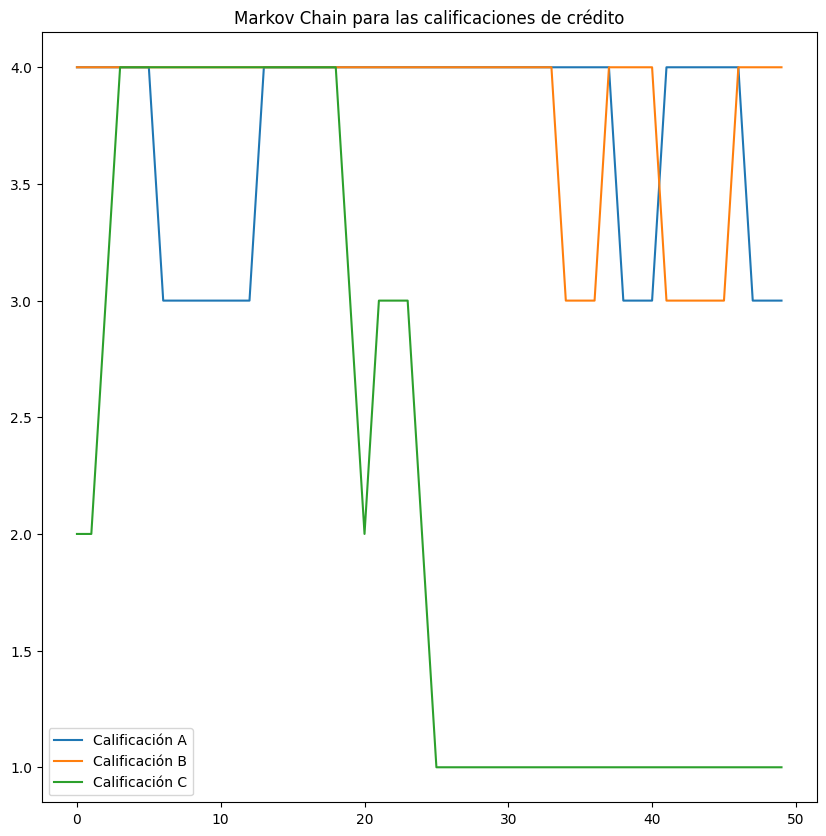

In [8]:
## Plot the results of resultado using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(resultado)
## Change the Labels to letters
## Change the Labels of axis y  to letters
plt.legend(["Calificación A","Calificación B","Calificación C"])
plt.title("Markov Chain para las calificaciones de crédito")


### Importance Sampling

El muestreo de importancia es una técnica estadística utilizada en teoría de probabilidad y estadísticas, particularmente en el contexto de simulaciones de Monte Carlo e integración numérica. Está diseñada para estimar propiedades de una distribución de probabilidad particular mediante la generación de muestras de una distribución de probabilidad diferente, generalmente más simple. El objetivo es mejorar la precisión de las estimaciones de ciertas propiedades o expectativas de interés.

Así es como funciona el muestreo de importancia:

1. **Distribución Objetivo**: Tienes una distribución de probabilidad (la distribución objetivo) de la cual deseas estimar ciertas propiedades, como la media, la varianza o probabilidades específicas.

2. **Distribución de Importancia**: Se elige otra distribución de probabilidad (la distribución de importancia) que tiene algunas ventajas, como ser más fácil de muestrear o tener propiedades más favorables para las propiedades de interés. Esta distribución debe tener una probabilidad distinta de cero donde la distribución objetivo contribuye significativamente a las propiedades deseadas.

3. **Ponderación**: Para cada muestra obtenida de la distribución de importancia, se calcula un peso. El peso refleja cuán importante es la muestra en la estimación de las propiedades de la distribución objetivo. Normalmente, es la razón entre la densidad de probabilidad de la distribución objetivo y la densidad de probabilidad de la distribución de importancia en ese punto de muestra.

4. **Estimación**: Se utilizan las muestras ponderadas para estimar las propiedades de la distribución objetivo. Por ejemplo, para estimar la media de la distribución objetivo, se calcula el promedio ponderado de las muestras, donde cada muestra recibe un peso de acuerdo con el peso de importancia.

La idea clave detrás del muestreo de importancia es centrar los esfuerzos de muestreo en regiones donde la distribución objetivo contribuye más a las propiedades de interés. Esto puede mejorar significativamente la eficiencia y precisión de las simulaciones de Monte Carlo en comparación con el muestreo aleatorio simple.

El muestreo de importancia es particularmente útil cuando:

- La distribución objetivo es compleja o difícil de muestrear directamente.
- Se tienen intereses en eventos raros o probabilidades en las colas de la distribución.
- La distribución está altamente sesgada y la mayor parte de la masa de probabilidad está concentrada en una pequeña parte del espacio.

Sin embargo, es importante elegir una distribución de importancia adecuada; de lo contrario, las estimaciones pueden ser sesgadas o ineficientes. La eficiencia del muestreo de importancia depende de qué tan bien la distribución de importancia aproxima la distribución objetivo para las propiedades de interés.



Como se puede observar en la figura, un cliente puede iniciar con una calificación que puede ser A la azul, B la naranja o C la verde y cambiar de calificación a medida que pasan los meses. Si el cliente se declara en bancarrota, como pasa con la linea verde, se asume que se prestamo no se podrá cobrar. Para este gráfico en el eje y, la calificación A tiene un puntaje de 4, la calificación B tiene un puntaje de 3, la calificación C tiene un puntaje de 2 y si se declara en bancarrota tiene un puntaje de 1.

### Ejemplo Importance Sampling

(array([-10000.,      0.,  10000.,  20000.,  30000.,  40000.,  50000.,
         60000.]),
 [Text(-10000.0, 0, '−10000'),
  Text(0.0, 0, '0'),
  Text(10000.0, 0, '10000'),
  Text(20000.0, 0, '20000'),
  Text(30000.0, 0, '30000'),
  Text(40000.0, 0, '40000'),
  Text(50000.0, 0, '50000'),
  Text(60000.0, 0, '60000')])

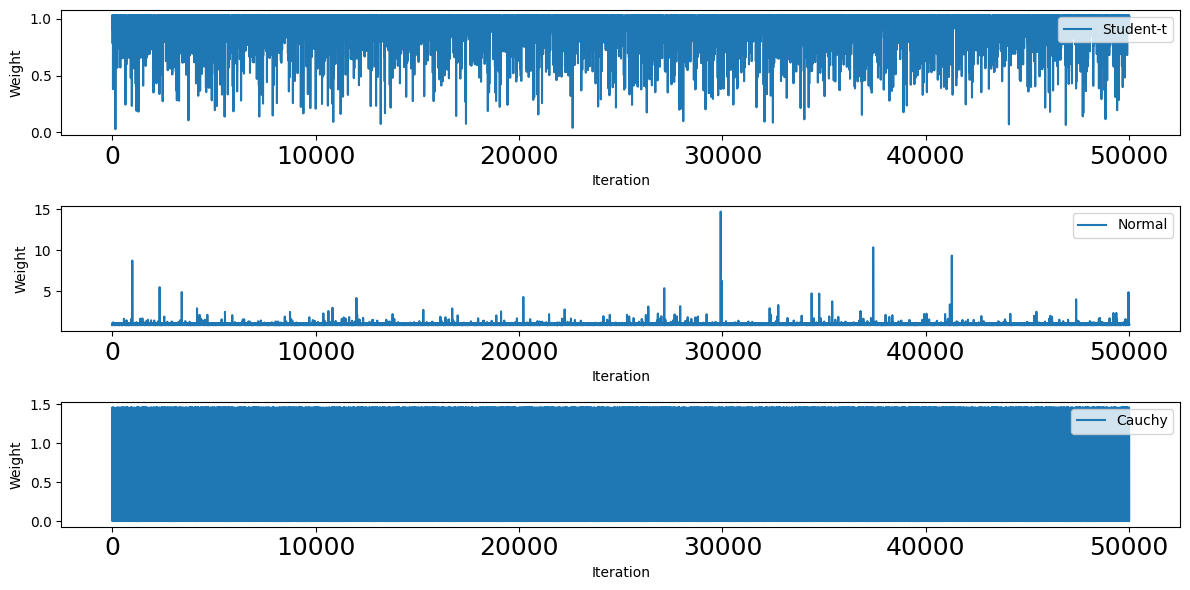

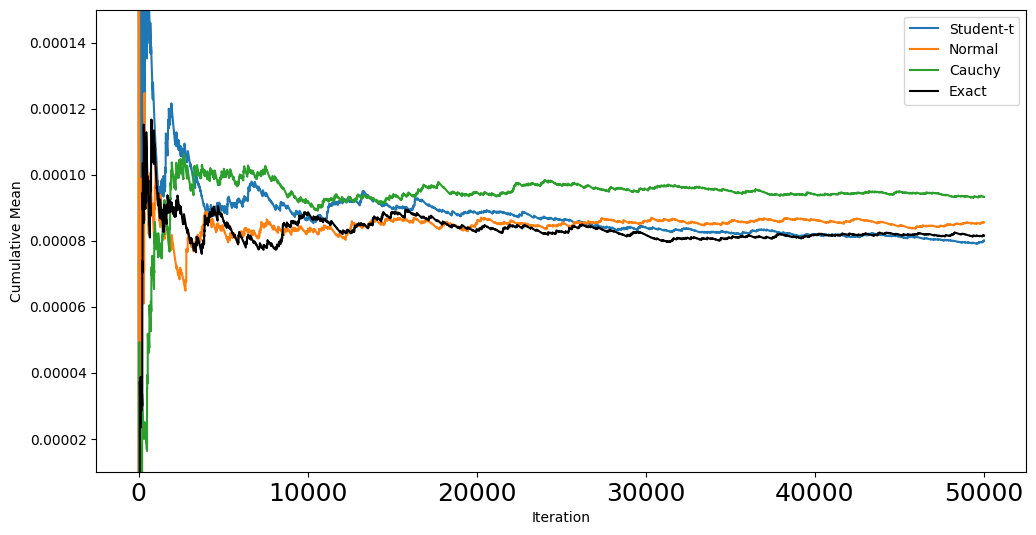

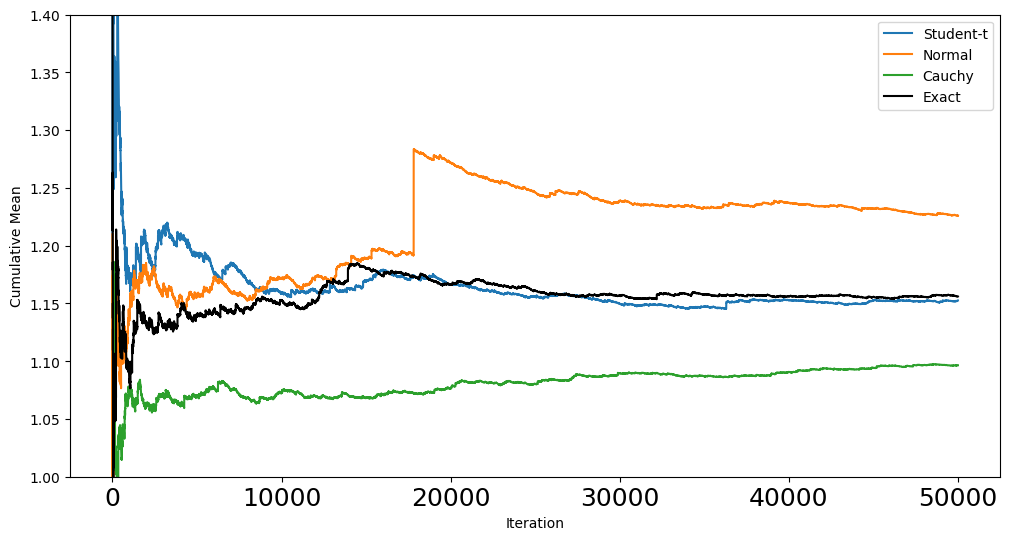

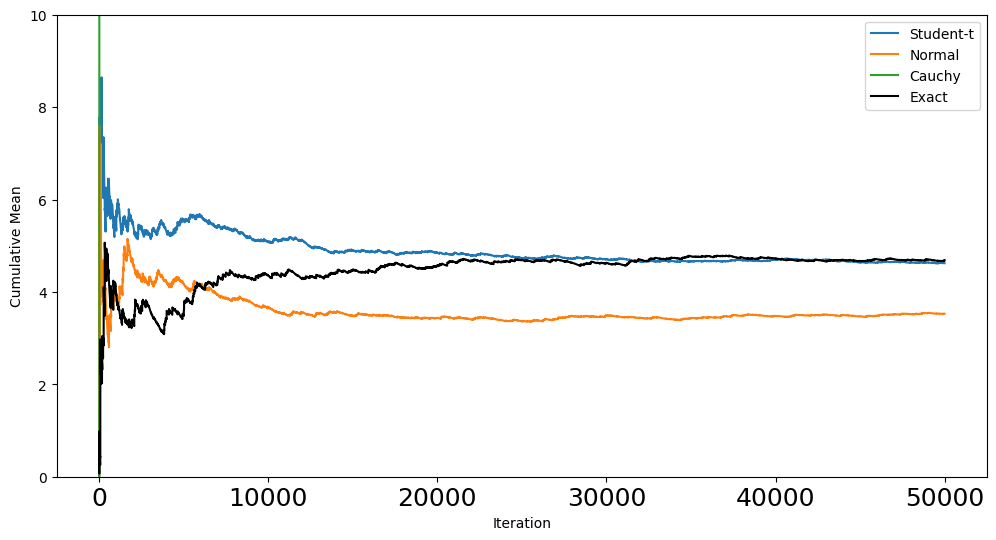

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm, cauchy

# Define parameters
nu = 12
nustar = 7
nIS = 50000

# Initialize arrays
mu1IS = np.zeros((nIS, 4))
mu2IS = np.zeros((nIS, 4))
mu3IS = np.zeros((nIS, 4))

mu1IScum = np.zeros((nIS, 4))
mu2IScum = np.zeros((nIS, 4))
mu3IScum = np.zeros((nIS, 4))

wIS = np.zeros((nIS, 3))



def w1(x, nu, nustar):
    # Importance weight calculation for Proposal 1 (Student-t distribution)
    pdf_x = t.pdf(x, df=nu)
    pdf_nustar = t.pdf(x, df=nustar)
    return pdf_x / pdf_nustar

def w2(x, nu):
    # Importance weight calculation for Proposal 2 (Normal distribution)
    pdf_x = t.pdf(x, df=nu)
    pdf_normal = norm.pdf(x, loc=0, scale=np.sqrt(nu / (nu - 2)))
    return pdf_x / pdf_normal

def w3(x, nu):
    # Importance weight calculation for Proposal 3 (Cauchy distribution)
    pdf_x = t.pdf(x, df=nu)
    pdf_cauchy = cauchy.pdf(x, loc=0, scale=1)
    return pdf_x / pdf_cauchy


# Main loop
for i in range(nIS):
    # Proposal 1
    x1 = np.random.standard_t(nustar)
    # Proposal 2
    x2 = np.random.normal(0, np.sqrt(nu / (nu - 2)))
    # Proposal 3
    x3 = cauchy.rvs(loc=0, scale=np.sqrt(nu / (nu - 2)), size=1)
    # Exact
    x4 = np.random.standard_t(nu)

    # Importance weights
    wIS[i, 0] = w1(x1, nu, nustar)
    wIS[i, 1] = w2(x2, nu)
    wIS[i, 2] = w3(x3, nu)

    # f_1
    mu1IS[i, 0] = ((np.sin(x1) / x1) ** 5) * (x1 > 2.1)
    mu1IS[i, 1] = ((np.sin(x2) / x2) ** 5) * (x2 > 2.1)
    mu1IS[i, 2] = ((np.sin(x3) / x3) ** 5) * (x3 > 2.1)
    mu1IS[i, 3] = ((np.sin(x4) / x4) ** 5) * (x4 > 2.1)

    # f_2
    mu2IS[i, 0] = np.sqrt(abs(x1 / (1 - x1)))
    mu2IS[i, 1] = np.sqrt(abs(x2 / (1 - x2)))
    mu2IS[i, 2] = np.sqrt(abs(x3 / (1 - x3)))
    mu2IS[i, 3] = np.sqrt(abs(x4 / (1 - x4)))

    # f_3
    mu3IS[i, 0] = (x1 ** 5 / (1 + (x1 - 3) ** 2)) * (x1 > 0)
    mu3IS[i, 1] = (x2 ** 5 / (1 + (x2 - 3) ** 2)) * (x2 > 0)
    mu3IS[i, 2] = (x3 ** 5 / (1 + (x3 - 3) ** 2)) * (x3 > 0)
    mu3IS[i, 3] = (x4 ** 5 / (1 + (x4 - 3) ** 2)) * (x4 > 0)

    #if i % 1000 == 0:
        #print(i)

# Initialize cumulative sum arrays
mu1IScum = np.zeros((nIS, 4))
mu2IScum = np.zeros((nIS, 4))
mu3IScum = np.zeros((nIS, 4))

# Calculate cumulative sums
for i in range(nIS):
    for j in range(4):
        mu1IScum[i, j] = np.sum(mu1IS[:i+1, j] * wIS[:i+1, 0]) / (i + 1)
        mu2IScum[i, j] = np.sum(mu2IS[:i+1, j] * wIS[:i+1, 0]) / (i + 1)
        mu3IScum[i, j] = np.sum(mu3IS[:i+1, j] * wIS[:i+1, 0]) / (i + 1)

# Create plots
fs = 18

# Plotting for wIS
plt.figure(1, figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(np.arange(1, nIS + 1), wIS[:, 0])
plt.legend(['Student-t'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.xticks(fontsize=fs)

plt.subplot(3, 1, 2)
plt.plot(np.arange(1, nIS + 1), wIS[:, 1])
plt.legend(['Normal'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.xticks(fontsize=fs)

plt.subplot(3, 1, 3)
plt.plot(np.arange(1, nIS + 1), wIS[:, 2])
plt.legend(['Cauchy'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Weight')
plt.xticks(fontsize=fs)

plt.tight_layout()

# Plotting for mu1IScum
plt.figure(2, figsize=(12, 6))
plt.plot(np.arange(1, nIS + 1), mu1IScum[:, :3])
plt.plot(np.arange(1, nIS + 1), mu1IScum[:, 3], '-k')
plt.legend(['Student-t', 'Normal', 'Cauchy', 'Exact'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Mean')
plt.ylim([0.00001, 0.00015])
plt.xticks(fontsize=fs)

# Plotting for mu2IScum
plt.figure(3, figsize=(12, 6))
plt.plot(np.arange(1, nIS + 1), mu2IScum[:, :3])
plt.plot(np.arange(1, nIS + 1), mu2IScum[:, 3], '-k')
plt.legend(['Student-t', 'Normal', 'Cauchy', 'Exact'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Mean')
plt.ylim([1, 1.4])
plt.xticks(fontsize=fs)

# Plotting for mu3IScum
plt.figure(4, figsize=(12, 6))
plt.plot(np.arange(1, nIS + 1), mu3IScum[:, :3])
plt.plot(np.arange(1, nIS + 1), mu3IScum[:, 3], '-k')
plt.legend(['Student-t', 'Normal', 'Cauchy', 'Exact'], loc='upper right')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Mean')
plt.ylim([0, 10])
plt.xticks(fontsize=fs)



## Simulación Montecarlo

Usualmente la generación de número aleatorios por computador es sencilla y no requiere de grandes recursos para hacer un modelo básico que permite por ejemplo generar los resultados de lanzar un dado. A medida que los problemas se vuelven más complejos, los procesos de simulación que intentan representar formas analíticas o teóricas necesitan de un procesos que logren repsentar las particularidades generando convergencia en los resultados en tiempo menor al que se espera. 

Usando la ley de los grandes números se puede encontrar una representación del valor esperado de una integral que permita resolver procesos de optimización y simulación.

De hecho, una solución general es utilizar la simulación, ya sea de la distribución verdadera o de algunas distribuciones sustitutas, para calcular las cantidades de interés. En la configuración de la teoría de la decisión, ya sea clásica o bayesiana, esta solución es natural ya que los estimadores de riesgos y de Bayes involucran integrales con respecto a las distribuciones de probabilidad.

La solución clásica para obtener un valor esperado es la que presenta la integral

$$E_{f}[h(X)]=\int_{x} h(x) f(x)dx $$

Donde se tiene una densidad $f$, $X$ es una variable aleatoria y la función $h$ es la que queremos modelar. Esta se obtiene a través de un promedio simplement

$$\overline{h}_{n}=\frac{1}{n}\sum_{j=1}^{n}h(x_{j})$$


Siguiendo las propiedades de la varianza, se puede obtener esta medidar usando el proceso de integración:

$$V(\overline{h}_{n})=\frac{1}{n}\int_{x}(h(x)-E_{f}[h(x)])^2 f(x)dx $$

Que se obtiene de la muestra $X_{1},...,X_{n}$ de la función $h$.

$$v_{n}=\frac{1}{n}\sum_{j=1}^{n}(h(x_{j})-\overline{h}_{n})^2$$

Si bien la bonificación que aporta la evaluación simultánea del error de la estimación de Monte Carlo no se puede discutir, debe tener en cuenta que solo es confiable en la medida en que $v_{n}$ sea una estimación adecuada de la varianza de $h_{n}$. En situaciones críticas en las que $v_{n}$ no converge en absoluto o ni siquiera converge lo suficientemente rápido para que se aplique un teorema del límte central, no se puede confiar en esta estimación y la región de confianza asociada a ella.


Por ejemplo usando el estimador de Bayes para una simulación Cauchy:

$$\delta(x)=\int_{-\infty}^{\infty} \frac{\theta}{1+\theta^2} \exp(-(x-\theta)^2x^2)d\theta/ \int_{-\infty}^{\infty} \frac{1}{1+\theta^{2}} \exp(-(x-\theta)^{2})/2)d\theta $$


Usando valores para $x=0,2,4$ se realizarán los siguientes pasos:

1. Graficar las integrales para los valores de $x$ y usar integración montecarlo basada en la simulación Cauchy para calcular las integrales.
2. Monitorear la convergencia de la estimación de la varianza,  con el error estandar del estimado.
3. Repetir el experimento usando integración Montecarlo basada en una simulación de la distribución normal. (tarea)

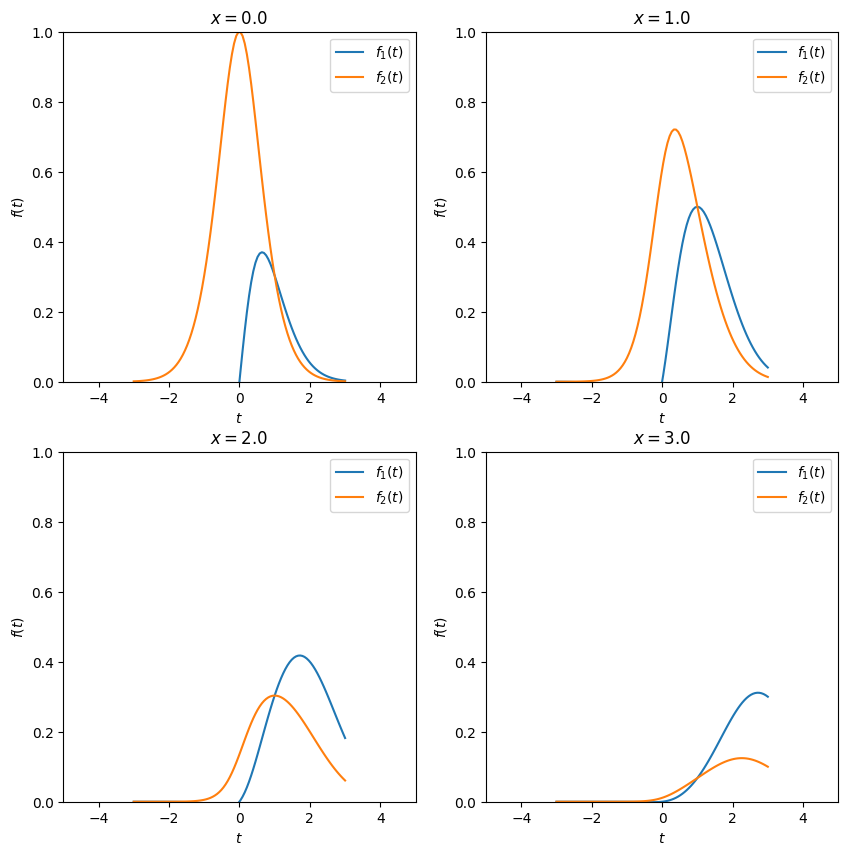

In [9]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import math



## Create function to compute the integral

def montecarlo1(t,x):
    return (t/(1+t**2))*np.exp(-(x-t)**2/2)
   

def montecarlo2(t,x):
    return (1/(1+t**2))*np.exp(-(x-t)**2/2)
    

t=np.linspace(-3,3,100)
x=np.array([0.0,1.0,2.0,3.0])
plt.figure(figsize=(10,10))

for i in range(len(x)):
    f1=montecarlo1(t,x[i])
    f2=montecarlo2(t,x[i])
    plt.subplot(2,2,i+1)
    plt.plot(t,f1,label="$f_1(t)$")
    plt.plot(t,f2,label="$f_2(t)$")
    plt.legend()
    plt.title("$x={}$".format(x[i]))
    plt.xlabel("$t$")
    plt.ylabel("$f(t)$")
    plt.xlim(-5,5)
    plt.ylim(0,1)









    


Después de graficar las integrales, se puede observar que la convergencia de la estimación de la varianza es muy lenta. Ahora se obtiene la división de acuerdo ala media de cada distribución.

In [10]:
Niter=1000
co=np.random.standard_cauchy(Niter)

x=0
I1=np.mean(co*norm.pdf(x,co))/np.mean(norm.pdf(x, co))
x=2
I2=np.mean(co*norm.pdf(x,co))/np.mean(norm.pdf(x, co))
x=4
I3=np.mean(co*norm.pdf(x,co))/np.mean(norm.pdf(x, co))

print(I1,I2,I3)


0.004101416504374683 1.3283972975230194 3.394985760123274


Se puede observar que a medida que se aumenta x aumenta la razón entre la media de la distribución y la varianza Cauchy y Normal

In [11]:
x=0
x1=norm.pdf(x,co)
vec=np.linspace(1,Niter,Niter)
estint2=np.cumsum(x1)/(vec)
a=np.cumsum((x1-estint2)**2)
exterr2=np.zeros(Niter)
for i in range(len(a)):
    exterr2[i]= math.sqrt(a[i])/(vec[i])



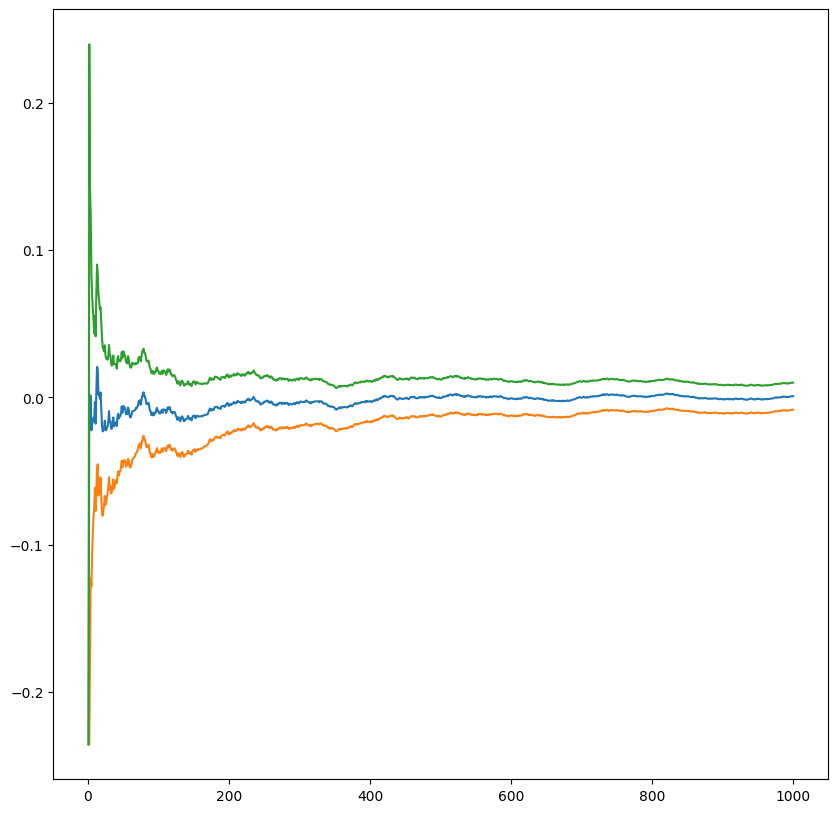

In [12]:
x1=co*x1
estint1=np.cumsum(x1)/(vec)
a=np.cumsum((x1-estint1)**2)
exterr1=np.zeros(Niter)
for i in range(len(a)):
    exterr1[i]= math.sqrt(a[i])/(vec[i])
## Plot the results 
plt.figure(figsize=(10,10))
plt.plot(vec,estint1,label="$\int_0^1 f(x)$")
plt.plot(vec,estint1-2*exterr1,label="$\int_0^1 f(x)$")
plt.plot(vec,estint1+2*exterr1,label="$\int_0^1 f(x)$")





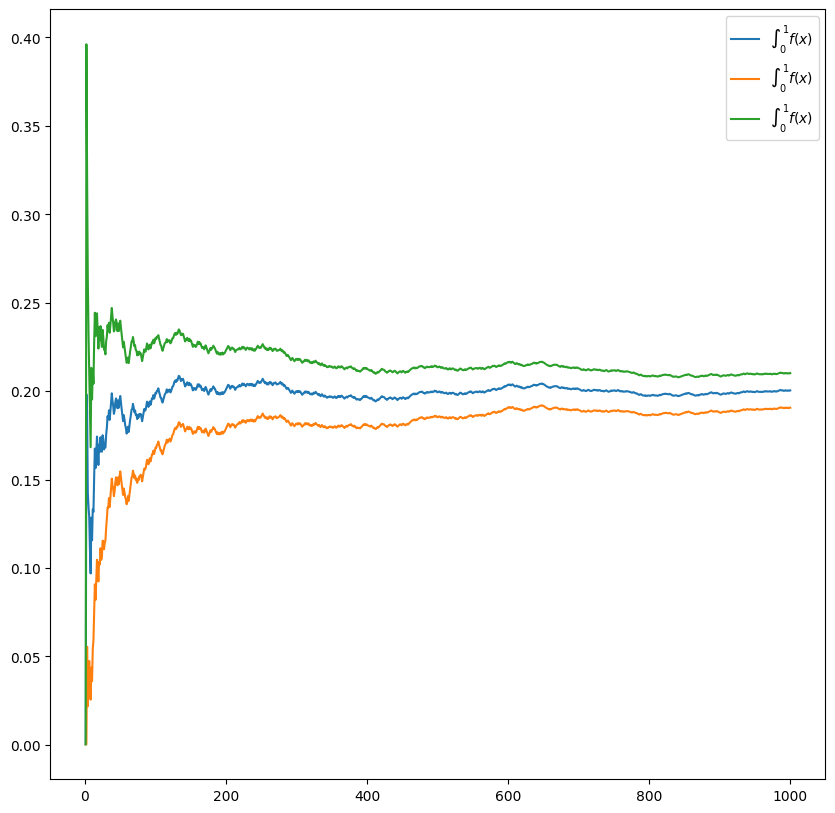

In [12]:
plt.figure(figsize=(10,10))
plt.plot(vec,estint2,label="$\int_0^1 f(x)$")
plt.plot(vec,estint2-2*exterr2,label="$\int_0^1 f(x)$")
plt.plot(vec,estint2+2*exterr2,label="$\int_0^1 f(x)$")
plt.legend()

Dentro de la inferencia bayesiana, tanto las cadenas de markov como la simulación montecarlo son herramientas que permiten encontrar el valor promedio de los parámetros en diferentes etapas del procesos de estimación 
como es obtener los parámetros de una distribución posterior usando las diferentes variaciones que se han revisado hasta este momento.

Estos procesos requieren de  procesos de programación y recursos computacionales que pueden ser muy costosos. Por esta razón, uno de los problemas que más se estudia en estos temas es analisar como se pueden
mejorar estos procesos de estimación. Uno de los procedimientos más comunes es usar un proceso de optimización que permita encontrar los mejores estimadores en el menor tiempo posible.

### Convergencia y varianza de la simulación de Montecarlo

Uno de los principales desafíos de la estimación de los parámetros en estadística es mantener una varianza constante que aumenta  a medida que avanza el tiempo. Generalmente solo se tiene en cuenta los valores promedios de una media $\overline{}h_{n}$ y la varianza $\overline{v}_{n}$ pero se deja de lado la correlación entre las iteraciones, para obtener un buen intervalo de confianza se necesita toda la estructura.

Existen algunos métodos que ayuda a obtener estos valores como el de Bootstraping, pero es muy costoso porque requiere crear un misma secuencia y esto genera mazores variaciones de la media y varianza dificultando el proceso de convergencia.

Usando el mismo ejemplo de la distribución de Cauchy, se presenta la dificultad de evaluar la convergencia. 


Para una variable aleatoria $X \sim N(\theta,1)$ con $\theta \sim Cauchy(0,1)$ la esperanza posterior de ek promedio de $\theta$ es:

$$\delta^{\pi}(x)=\int_{-\infty}^{\infty} \frac{\theta}{1+\theta^2} \exp(-(x-\theta)^2x^2)d\theta/ \int_{-\infty}^{\infty} \frac{1}{1+\theta^{2}} \exp(-(x-\theta)^{2})/2)d\theta $$

En donde la aproximación de $\delta^{\pi}(x)$ se puede basar en la simulación de los partámetros $\theta \sim N(x,1)$.

$$\delta^{\pi}_{n}(x)=\sum_{i=1}^{n} \frac{\theta_{i}}{1+\theta^{2}_{i}} / \sum_{i=1}^{n} \frac{1}{1+\theta_{i}^{2}}$$

Donde $\delta^{\pi}_{n}$ es el cambio de los estimadores que no tiene en cuenta el cambio de la varianza. Esto dificulta el proceso de simulación y su posterior convergencia. 

Para solucionar este problema existe el factor de Bayes:

$$\rho =\frac{m_{1}(x)}{m_{2}(x)}=\frac{\int_{\Theta_{1}}\pi_{1}(\theta_{1})f_{1}(x\mid \theta_{1})d\theta_{1}}{\int_{\Theta_{2}}\pi_{2}(\theta_{2})f_{2}(x\mid \theta_{2})d\theta_{2}}$$


Lo importante de este factor es que puede mostrar como diferentes modelos son consitentes de manera simultanea, algo que no es posible comprobar en la estadística clásica puesto que solo se enfoca en normalizar constantes sin tener en cuenta la relaciüon entre las itearaciones.

Como la constante no se conoce, esta se obtiene a través de la distribución marginal likelihood $m_{1}(x)$ y $m_{2}(x)$ y permite calcular la distribución posterior $\pi_{1}(\theta \mid x)= \tilde{\pi}_{1}(\theta)/c_{1} $ y $\pi_{2}(\theta \mid x)=\tilde{\pi}_{2}(\theta)/c_{2}$.

/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_89506/1145194707.py:22: RuntimeWarning: invalid value encountered in sqrt
  upper=esti[0,:]+2*np.sqrt(var/n)
/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_89506/1145194707.py:23: RuntimeWarning: invalid value encountered in sqrt
  lower=esti[0,:]-2*np.sqrt(var/n)
/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_89506/1145194707.py:31: RuntimeWarning: invalid value encountered in sqrt
  upperw=esti[0,:]+2*np.sqrt(varw*var/n)
/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_89506/1145194707.py:32: RuntimeWarning: invalid value encountered in sqrt
  lowerw=esti[0,:]-2*np.sqrt(varw*var/n)


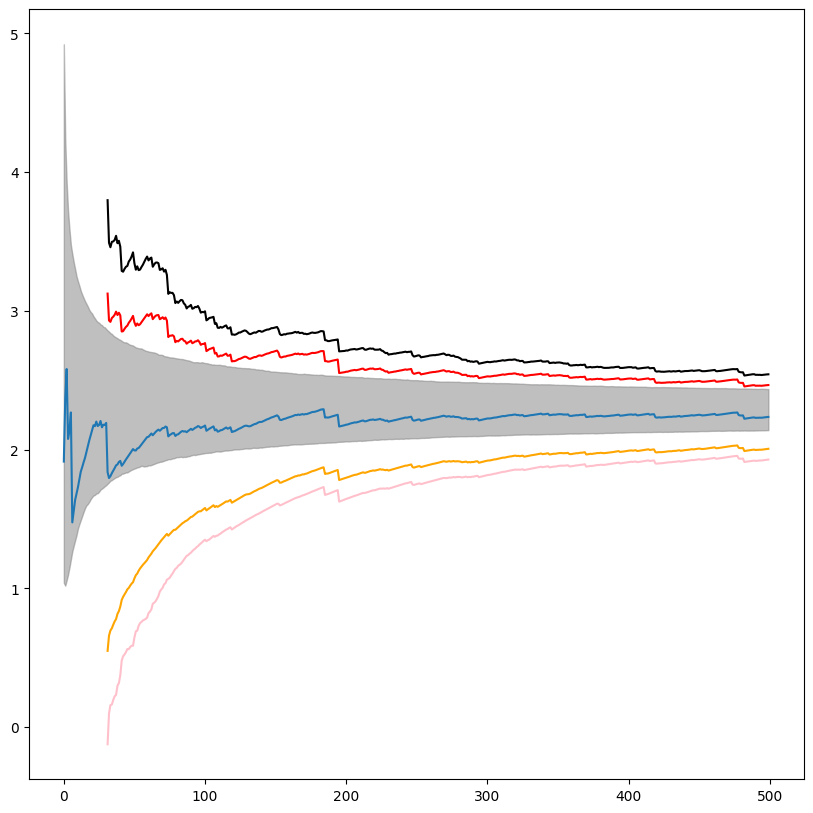

In [13]:
## Matrix with random normal distribution with mean 3 and std 1 with size 500 and 500
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import math
## set seed for reproducibility
np.random.seed(123)
norma=np.random.normal(3,1,(10000,500))
weit=1/(1+norma**2)
esti=np.cumsum(weit*norma, axis=1)/np.cumsum(weit, axis=1)
## plot the estimation 
plt.figure(figsize=(10,10))
plt.plot(esti[0,:],label="$\int_0^1 f(x)$")
## Get the quantiles from esti
q=np.percentile(esti, [2.5,97.5], axis=0)
plt.fill_between(np.arange(500),q[0,:],q[1,:],alpha=0.5,color="grey")
## var estimnation
var=np.cumsum(weit[0,:]*(norma[0,:]**2))/(np.cumsum(weit[0,:])-esti[0,:]**2)
## sum var rot to esti
n=np.linspace(1,500,500)
upper=esti[0,:]+2*np.sqrt(var/n)
lower=esti[0,:]-2*np.sqrt(var/n)
## plot upper an lower bond
plt.plot(upper,label="$\int_0^1 f(x)$", color="red")
plt.plot(lower,label="$\int_0^1 f(x)$", color="orange")

## weight correction

varw=np.cumsum((weit[0,:]**2))*n/(np.cumsum(weit[0,:])**2)
upperw=esti[0,:]+2*np.sqrt(varw*var/n)
lowerw=esti[0,:]-2*np.sqrt(varw*var/n)
## plot upper an lower bond
plt.plot(upperw,label="$\int_0^1 f(x)$", color="black")
plt.plot(lowerw,label="$\int_0^1 f(x)$", color="pink")


En la figura se muestra el factor de Bayes para calcular la varianza en la distribución de Cauchy así como el caluculo que se hace con un proceso de simulación en el que no se tiene en cuenta el cambio de la varianza en el tiempo y su relación con los datos anteriores. La linea azul es la estimación inicial, el area gris es el intervalo de confianza, la linea roja y naranja son los límites de la estimación cuando no se tiene en cuenta los cambios de la varianza y las lineas negras y rosadas son los límites cuando se es conciente del efecto de la varianza en la simulación. Esto mueestra que la aproximación bayesiana no subestima las variaciones en la simulación.  Finalmente se puede ver como el método de montecarlo converge pero las impliaciones en la amplitud de los intervalos de confianza son muy diferentes.

### Montecarlo Markov Chain MCMC

La idea básica detrás de MCMC es construir una cadena de Markov en el espacio de estados $X$ cuya distribución estacionaria es la densidad objetivo $p(x)$ de interés en una distribución prior o posterior. Se crea una caminata aleatoria por el espacio de estados, de tal manera que la fracción de tiempo que se cruza en cada estado $x$ es proporcional a $p(x)$. Dibujando  Muestras correlacionadas $x_{0}, x_{1}, x_{2}, ...,$ de la cadena se puede realizar la integración de Monte Carlo $p(x)$. 

La unión de estos de estos dos metodos tiene como objetivo princpial traer estabilidad a los procesos de estimación de los parámetros a través de la simulación que estacionaria y **recurrente** que significa que los valores retornan de forma arbitraria a un  valor medio infinitas veces.


$$\frac{1}{T} \sum_{i=1}^{T} h(X^{t}) \rightarrow E_{f}[h(X)]$$

Es decir para una simulación de una variable aleatoria $X_{t}$ siempre habrá un valor promedio. El único problema delos MCMC es que la convergencia es lenta y puede ser costosa.

De acuerdo a Robter(2001), esiste un caso cuando la convergencia no se obtiene y se relaciona directamente con pior impropias en modelos complejos. Es decir si esta no es integrable la cadena de makov no hallará una convergencia. Esta situación se profundizará en muestreos de Gibbs y Metropolitan Hastings.

La mayoría de estos algoritmos se pueden expresar de la siguiente manera.

1. Comience en la posición actual. (Estado Inicial)
2. Movimiento a una nueva posición.
3. Revisar la nueva posición en función de los datos y las distribuciones anteriores.
4. Después de una gran cantidad de iteraciones, obtenga los parámetros que está buscando.

El MCMC se profundizará en los métodos de muestreo de Gibbs y Metropolitian Hastings.


### Ejemplo predicción de un precio de un isntrumento financiero

En este ejemplo se usará el método de simulación montecarlo para estimar el precio de un instrumento financiero usando un proceso estocástico conocido como el movimiento geométrico browniano.

Este proceso se puede expresar de la siguiente manera:

Se inicia en precio $S_0$ y se mueve a una nueva posición $S_{t+1}$ de acuerdo a la siguiente ecuación:

$$S_{t+1}=S_t exp((\mu - 1/2 \sigma^{2})t+ \sigma_t\sqrt{t}\mathcal{N})$$

Donde $S_{t}$ es el precio del instrumento al momento $t$. $\mu$ es la tendencia de los rendimientos de un precio, $\sigma$ es la desviación estándar de los rendimientos y $\sqrt{t}\mathcal{N} $ es la representación del movimiento  browniano.

Un movimiento browniano es un proceso estocástico que se puede representar de la siguiente manera:

$$ W(t)=\sqrt{t}\mathcal{N}$$

Su distribución es normal con media cero y desviación estándar $\sqrt{t}$.

En este ejecicio se relizará los siguien pasos:

1. Se descargan los precios de un acción cualquiera
2. Se calcula la  tendecia y desviación estandar de los rendimientos.
3. Se implementa la ecuación usando un proceso de simulación montecarlo.
4. Graficamos los resultados para 10.000 escenarios.
5. Se obtiene la el valor esperado del precio de la acción y su límite superior e inferior.

El método montecarlo que se utiliza para resolver la ecuación del precio de una acción es:

$$ S_{t+1}=S_{t}+S_{t}\mu dt+S_{t}\sigma\sqrt{dt}\mathcal{N}$$

Siendo este resultado  una solución en términos de derivada con respecto $dt$ al tiempo de la ecuación original.

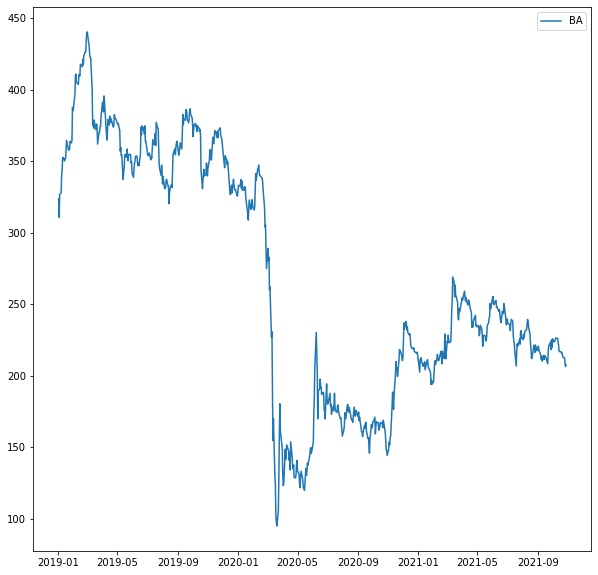

In [83]:
import pandas as pd
import numpy as np
import pandas_datareader as web
import matplotlib.pyplot as plt
from scipy.stats import norm

ba=web.DataReader("BA", "yahoo", start="2019-01-01", end="2021-10-28")

## plot the price of the company

plt.figure(figsize=(10,10))
plt.plot(ba.index,ba["Close"],label="BA")
plt.legend()


Text(0.5, 1.0, 'Histogram of the returns')

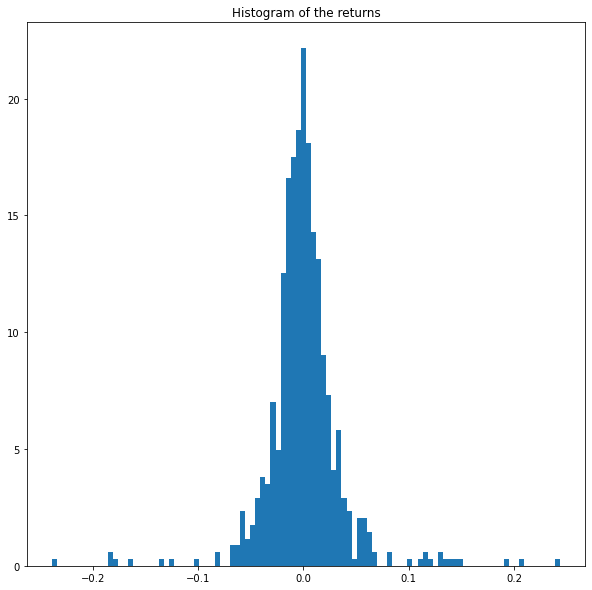

In [82]:
## Get the returns of the company
bar=ba["Close"].pct_change()
mean=np.mean(bar)
sd=np.std(bar)
## plot the histogram of the returns
plt.figure(figsize=(10,10))
plt.hist(bar,bins=100,density=True)
plt.title("Histogram of the returns")


In [117]:
### Generate 10000 simulations using itearative method

## create a matrix of zeros with size 1000 x 10000

S=np.zeros((1000,10000))
S[:,0]=ba["Close"].iloc[-1]
dt=0.01
mb=np.sqrt(dt)*np.random.randn(1000,10000)


    


In [118]:
for i in range(result.shape[1]-1):

    S[:,i+1]=S[:,i]+S[:,i]*mean*dt+S[:,i]*sd*mb[:,i]


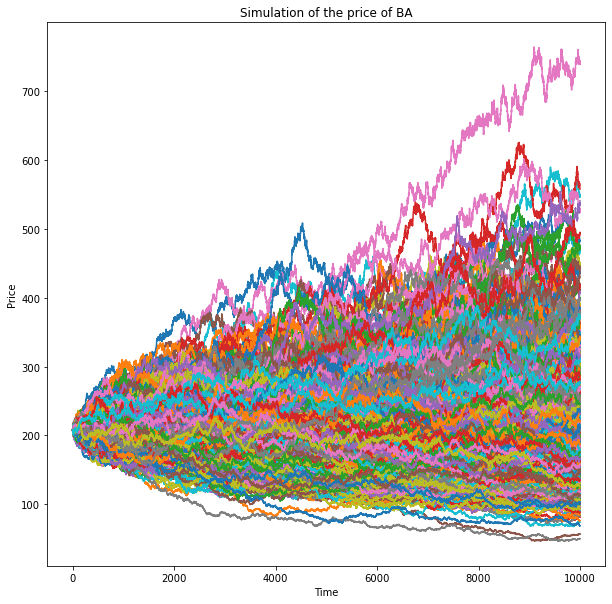

In [107]:
### Plot the results of S
plt.figure(figsize=(10,10))
for i in range(S.shape[0]):
    plt.plot(S[i,:],label="Simulation BA")
    plt.title("Simulation of the price of BA")
    ## y and x labels
    plt.ylabel("Price")
    plt.xlabel("Time")


In [110]:
### Get the expect value and standard deaviation from S by taking the mean of the simulations of each column
exvalues=np.mean(S,axis=0)
std=np.std(S,axis=0)

upperl=exvalues+2*std
lowerl=exvalues-2*std

Text(0.5, 0, 'Time')

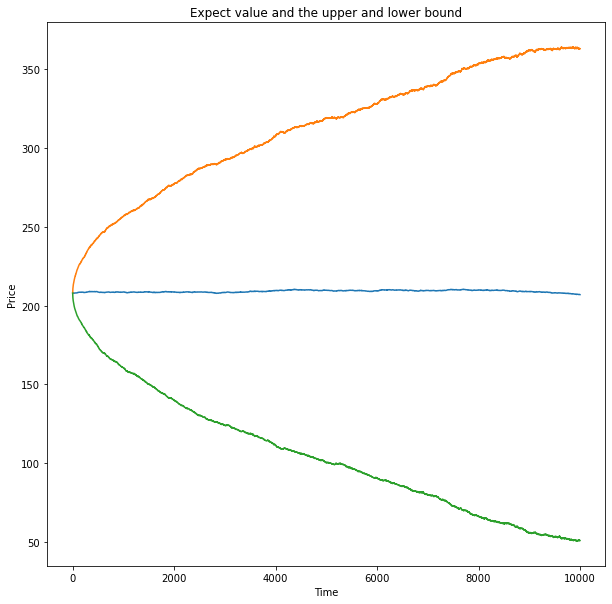

In [112]:
### Plot the expecte value and the upper and lower bound
plt.figure(figsize=(10,10))
plt.plot(exvalues,label="Expect value")
plt.plot(upperl,label="Upper bound")
plt.plot(lowerl,label="Lower bound")
plt.title("Expect value and the upper and lower bound")
plt.ylabel("Price")
plt.xlabel("Time")

El modelo geométrico browniano se puede representar a través de una simulación montecarlo que cumple con los requisitos de una cadena de markov. En cierta medida es un MCMC, en donde el precio se encuentra en estado específico y pasa al siguiente con cierta probabilidad. 

El resultado del ejemplo anterior se puede resumir en los siguientes pasos:

1. Una vez que se obtienen la media y la desviación estándar de los rendimientos diarios se implementa el método montecarlo.
2. Se plantea un escenario de 100 días en donde $dt=0.01$ para 10000 iteraciones.
3. Se generan todos los escenarios posibles usando la solución de la ecuación en la que se deriva con respecto al tiempo.
4. Se grafica el resultado que es un tornado.
5. Se obtiene el valor esperado del precio de la acción y su límite superior e inferior.
6. Se grafica el valor esperado del precio de la acción y su límite superior e inferior.

Como se puede observar la linea azul es un precio promedio y la linea verde y rojas son las variaciones máximas que se esperan del precio en un período de 100 días.

Finalmente, se puede observar la convergencia del precio a su valor medio, en donde entre más simulaciones se realizan estas muestran un precio promedio alrededor del precio actual. Esto índica que este método mantiene los precios dentro de unos límites que se esperan deben ser los mismos que aparecen en el mercado.